# Notebook para entrenar modelos

2026-01-08 21:23:52.526658: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-08 21:23:52.533593: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-08 21:23:52.637359: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-08 21:23:52.702372: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767918232.806687 2525463 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767918232.83

Usando minst como dataset


2026-01-08 21:24:04.588253: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - kl_loss: 1.9726 - loss: 45.5662 - reconstruction_loss: 43.6031 - val_kl_loss: 2.3741 - val_loss: 30.4328 - val_reconstruction_loss: 28.0788
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 2.2887 - loss: 25.0219 - reconstruction_loss: 22.7352 - val_kl_loss: 2.0910 - val_loss: 20.8916 - val_reconstruction_loss: 18.7909
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 1.8879 - loss: 18.9466 - reconstruction_loss: 17.0588 - val_kl_loss: 1.7030 - val_loss: 17.2931 - val_reconstruction_loss: 15.5747
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - kl_loss: 1.6554 - loss: 16.0832 - reconstruction_loss: 14.4277 - val_kl_loss: 1.5302 - val_loss: 15.1229 - val_reconstruction_loss: 13.5673
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 1.4973 - loss: 14.2329 - reconstruction_loss: 12.7353 - val_kl_loss: 1.3903 - val_loss: 13.6553 - val_reconstruction_loss: 12.2279
Epoch 6/1000
43

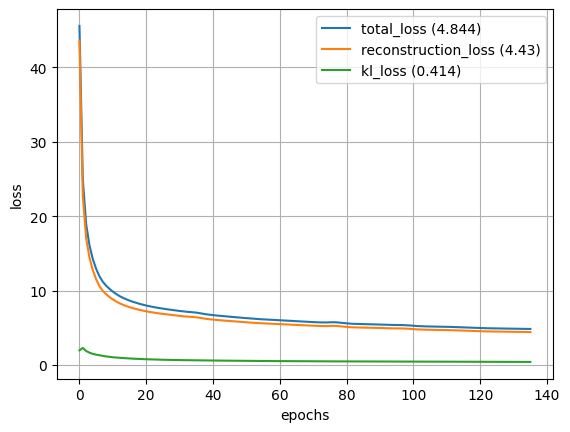

In [ ]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

import project.loader.load as load
from project.models_definitions import encoder
from project.models_definitions import decoder
from project.models_definitions.cvae import CVAE 

import matplotlib.pyplot as plt

import tensorflow as tf
from keras.callbacks import EarlyStopping

## parametros
dataset="minst"
data = load.data(dataset=dataset)

x_train = data["x_train"]
y_train = data["y_train"]

x_test = data["x_test"]
y_test =data["x_test"]

x_val = data["x_val"]
y_val = data["y_val"]

original_dim = 28*28
beta = 1.0

train_dataset = tf.data.Dataset.from_tensor_slices(((x_train, y_train), x_train))
train_dataset = train_dataset.batch(128)

val_dataset = tf.data.Dataset.from_tensor_slices(((x_val, y_val), x_val))
val_dataset = val_dataset.batch(128)


#intermediate_dim = [128,128,256,256,512,512,1024,784 ,1024]
#latent_dim =      [2  ,64 ,64 ,128,128,256,256,784 ,512]
intermediate_dim = [260]
latent_dim =      [128]


for i in range(len(intermediate_dim)):


    en = encoder.build_enconder(
        intermediate_dim=intermediate_dim[i],
        latent_dim=latent_dim[i],
    )
    de = decoder.build_decoder(
        intermediate_dim=intermediate_dim[i],
        latent_dim=latent_dim[i],
    )
    cvae_model = CVAE(
        encoder=en,
        decoder=de,
        original_dim=original_dim,
        beta=beta,
    )


    optimizer = tf.keras.optimizers.Adam()
    cvae_model.compile(optimizer=optimizer)


    cvae_model.total_loss_tracker.reset_state()
    cvae_model.reconstruction_loss_tracker.reset_state()
    cvae_model.kl_loss_tracker.reset_state()

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    history = cvae_model.fit(
        train_dataset,
        epochs=10,
        batch_size=128,
        validation_data=val_dataset,
        callbacks=[early_stopping],
        verbose=1
    )

    en.save(f"en_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}.keras")
    de.save(f"de_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}.keras")


    plt.plot(history.history["loss"], label=f"total_loss ({round(history.history["loss"][-1],3)})")
    plt.plot(history.history["reconstruction_loss"], label=f"reconstruction_loss ({round(history.history["reconstruction_loss"][-1],3)})")
    plt.plot(history.history["kl_loss"], label=f"kl_loss ({round(history.history["kl_loss"][-1],3)})")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.grid()
    plt.legend()
    plt.savefig(f"loss_vs_epochs_model_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}")
    plt.show()

### Varios modelos. Cambio de espacio intermedio

Usando mnist como dataset
Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - kl_loss: 1.6388 - loss: 51.3142 - reconstruction_loss: 49.6844 - val_kl_loss: 2.0439 - val_loss: 36.5590 - val_reconstruction_loss: 34.5279
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - kl_loss: 2.0263 - loss: 30.9457 - reconstruction_loss: 28.9215 - val_kl_loss: 1.8369 - val_loss: 26.8966 - val_reconstruction_loss: 25.0471
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - kl_loss: 1.9214 - loss: 24.1509 - reconstruction_loss: 22.2305 - val_kl_loss: 1.7890 - val_loss: 21.9527 - val_reconstruction_loss: 20.1429
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - kl_loss: 1.6459 - loss: 20.6155 - reconstruction_loss: 18.9698 - val_kl_loss: 1.5144 - val_loss: 19.5136 - val_reconstruction_loss: 17.9800
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 1.4850 - loss: 18.5690 - reconstruction_loss: 17.0839 - val_kl_loss: 1.4026 - val_loss: 17.7570 - val_reconstruction_loss: 1

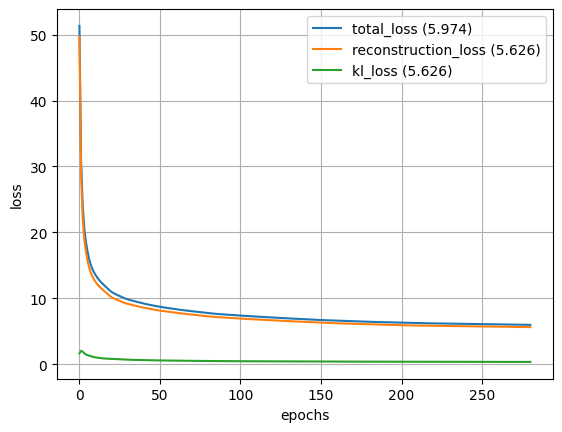

Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 1.8230 - loss: 49.8896 - reconstruction_loss: 48.0760 - val_kl_loss: 2.1969 - val_loss: 34.8409 - val_reconstruction_loss: 32.6518
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - kl_loss: 2.0967 - loss: 29.8256 - reconstruction_loss: 27.7310 - val_kl_loss: 1.9734 - val_loss: 25.6478 - val_reconstruction_loss: 23.6612
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 1.9381 - loss: 23.1595 - reconstruction_loss: 21.2221 - val_kl_loss: 1.8394 - val_loss: 20.8909 - val_reconstruction_loss: 19.0295
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - kl_loss: 1.7512 - loss: 19.4519 - reconstruction_loss: 17.7006 - val_kl_loss: 1.6205 - val_loss: 18.2357 - val_reconstruction_loss: 16.5922
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 1.5868 - loss: 17.2670 - reconstruction_loss: 15.6800 - val_kl_loss: 1.4700 - val_loss: 16.4253 - val_reconstruction_loss: 14.9324
Epoch 6/1000
43

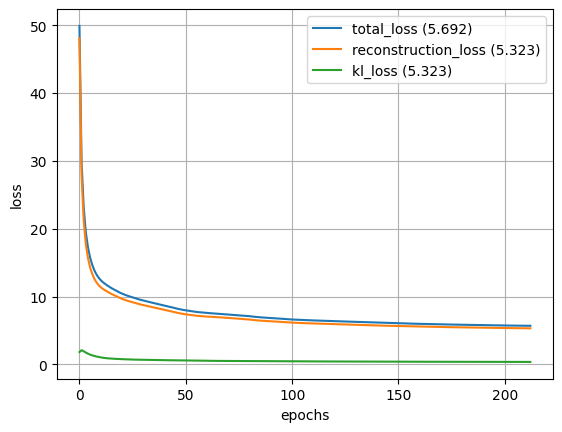

Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - kl_loss: 1.7839 - loss: 49.1083 - reconstruction_loss: 47.3339 - val_kl_loss: 2.2569 - val_loss: 33.9534 - val_reconstruction_loss: 31.7257
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 2.1148 - loss: 28.8121 - reconstruction_loss: 26.6994 - val_kl_loss: 2.0249 - val_loss: 24.6965 - val_reconstruction_loss: 22.6734
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - kl_loss: 1.9810 - loss: 21.9359 - reconstruction_loss: 19.9556 - val_kl_loss: 1.8280 - val_loss: 19.7470 - val_reconstruction_loss: 17.9136
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - kl_loss: 1.7496 - loss: 18.3083 - reconstruction_loss: 16.5588 - val_kl_loss: 1.5865 - val_loss: 17.1073 - val_reconstruction_loss: 15.5113
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 1.5824 - loss: 16.1956 - reconstruction_loss: 14.6131 - val_kl_loss: 1.4796 - val_loss: 15.3282 - val_reconstruction_loss: 13.8308
Epoch 6/1000
43

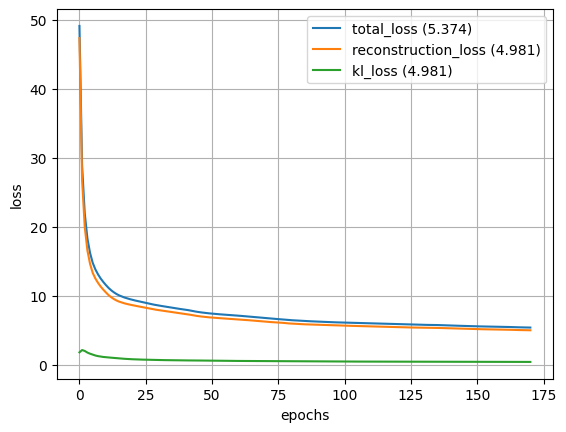

Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - kl_loss: 1.8687 - loss: 47.9973 - reconstruction_loss: 46.1380 - val_kl_loss: 2.0951 - val_loss: 33.1071 - val_reconstruction_loss: 31.0481
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - kl_loss: 2.1696 - loss: 27.8740 - reconstruction_loss: 25.7069 - val_kl_loss: 2.0990 - val_loss: 23.4028 - val_reconstruction_loss: 21.3065
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 1.9419 - loss: 21.0569 - reconstruction_loss: 19.1155 - val_kl_loss: 1.7664 - val_loss: 19.1773 - val_reconstruction_loss: 17.3926
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 1.6734 - loss: 17.9403 - reconstruction_loss: 16.2669 - val_kl_loss: 1.5088 - val_loss: 16.8457 - val_reconstruction_loss: 15.3164
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - kl_loss: 1.4571 - loss: 16.2084 - reconstruction_loss: 14.7511 - val_kl_loss: 1.3435 - val_loss: 15.5282 - val_reconstruction_loss: 14.1623
Epoch 6/1000
43

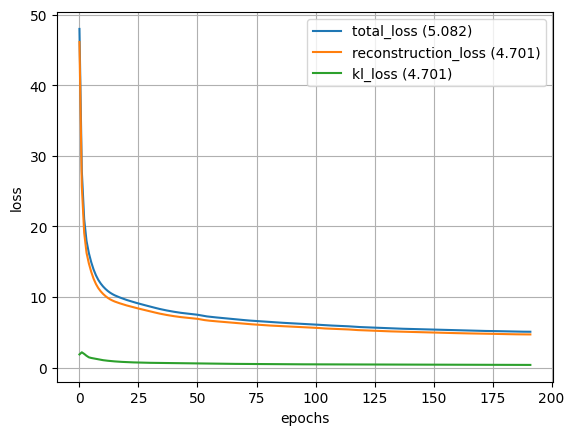

Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - kl_loss: 1.8781 - loss: 47.2804 - reconstruction_loss: 45.4119 - val_kl_loss: 2.1936 - val_loss: 32.3241 - val_reconstruction_loss: 30.1295
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 2.1290 - loss: 27.0541 - reconstruction_loss: 24.9271 - val_kl_loss: 1.9291 - val_loss: 23.1454 - val_reconstruction_loss: 21.2120
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 1.8874 - loss: 20.7175 - reconstruction_loss: 18.8307 - val_kl_loss: 1.7328 - val_loss: 18.6720 - val_reconstruction_loss: 16.9340
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - kl_loss: 1.6395 - loss: 17.5285 - reconstruction_loss: 15.8890 - val_kl_loss: 1.4967 - val_loss: 16.4981 - val_reconstruction_loss: 14.9951
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - kl_loss: 1.4877 - loss: 15.6712 - reconstruction_loss: 14.1834 - val_kl_loss: 1.3884 - val_loss: 14.9621 - val_reconstruction_loss: 13.5627
Epoch 6/1000
43

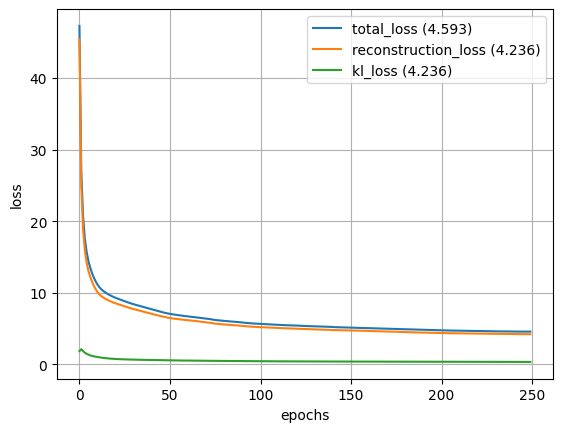

Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 1.9858 - loss: 46.4138 - reconstruction_loss: 44.4378 - val_kl_loss: 2.3194 - val_loss: 31.3594 - val_reconstruction_loss: 29.0476
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - kl_loss: 2.1204 - loss: 26.4565 - reconstruction_loss: 24.3383 - val_kl_loss: 1.8941 - val_loss: 22.5696 - val_reconstruction_loss: 20.6684
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - kl_loss: 1.8568 - loss: 20.3465 - reconstruction_loss: 18.4901 - val_kl_loss: 1.6424 - val_loss: 18.5357 - val_reconstruction_loss: 16.8827
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - kl_loss: 1.6016 - loss: 17.3250 - reconstruction_loss: 15.7234 - val_kl_loss: 1.4820 - val_loss: 16.1771 - val_reconstruction_loss: 14.6794
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - kl_loss: 1.5050 - loss: 15.2950 - reconstruction_loss: 13.7899 - val_kl_loss: 1.4240 - val_loss: 14.4439 - val_reconstruction_loss: 12.9970
Epoch 6/1000
430

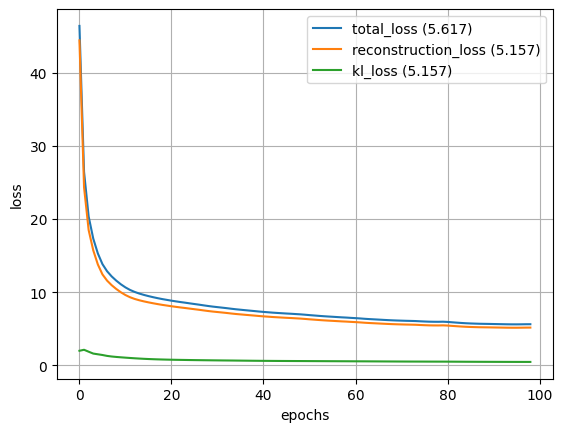

Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 1.9787 - loss: 45.9562 - reconstruction_loss: 43.9870 - val_kl_loss: 2.2159 - val_loss: 31.1222 - val_reconstruction_loss: 28.9199
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - kl_loss: 2.2691 - loss: 25.7650 - reconstruction_loss: 23.4984 - val_kl_loss: 2.1225 - val_loss: 21.3597 - val_reconstruction_loss: 19.2172
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - kl_loss: 1.9440 - loss: 19.1929 - reconstruction_loss: 17.2493 - val_kl_loss: 1.7469 - val_loss: 17.4224 - val_reconstruction_loss: 15.6624
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - kl_loss: 1.6834 - loss: 16.2071 - reconstruction_loss: 14.5238 - val_kl_loss: 1.5556 - val_loss: 15.1766 - val_reconstruction_loss: 13.5977
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - kl_loss: 1.5358 - loss: 14.3085 - reconstruction_loss: 12.7727 - val_kl_loss: 1.4126 - val_loss: 13.7138 - val_reconstruction_loss: 12.2739
Epoch 6/1000
430/43

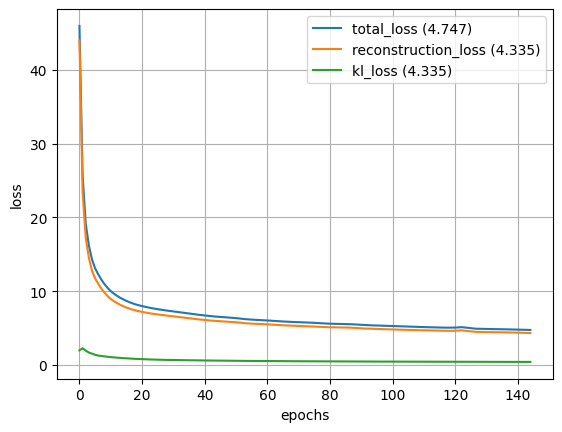

Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - kl_loss: 1.8502 - loss: 46.1771 - reconstruction_loss: 44.3359 - val_kl_loss: 2.1550 - val_loss: 31.4994 - val_reconstruction_loss: 29.3500
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - kl_loss: 2.2068 - loss: 26.0239 - reconstruction_loss: 23.8194 - val_kl_loss: 2.0661 - val_loss: 21.5836 - val_reconstruction_loss: 19.5028
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - kl_loss: 1.9433 - loss: 19.3701 - reconstruction_loss: 17.4272 - val_kl_loss: 1.7585 - val_loss: 17.4797 - val_reconstruction_loss: 15.7036
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - kl_loss: 1.6626 - loss: 16.3535 - reconstruction_loss: 14.6908 - val_kl_loss: 1.5363 - val_loss: 15.3430 - val_reconstruction_loss: 13.7828
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - kl_loss: 1.4985 - loss: 14.5218 - reconstruction_loss: 13.0231 - val_kl_loss: 1.4173 - val_loss: 13.7831 - val_reconstruction_loss: 12.3364
Epoch 6/10

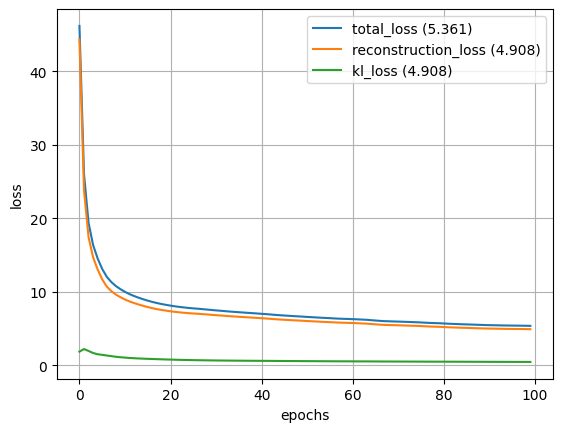

Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 31s 70ms/step - kl_loss: 2.0572 - loss: 45.3563 - reconstruction_loss: 43.3090 - val_kl_loss: 2.3796 - val_loss: 30.2173 - val_reconstruction_loss: 27.8480
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 30s 69ms/step - kl_loss: 2.2391 - loss: 24.9960 - reconstruction_loss: 22.7589 - val_kl_loss: 1.9899 - val_loss: 21.1586 - val_reconstruction_loss: 19.1623
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 30s 70ms/step - kl_loss: 1.8730 - loss: 19.0770 - reconstruction_loss: 17.2043 - val_kl_loss: 1.6877 - val_loss: 17.4371 - val_reconstruction_loss: 15.7285
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 30s 70ms/step - kl_loss: 1.6515 - loss: 16.0865 - reconstruction_loss: 14.4351 - val_kl_loss: 1.5267 - val_loss: 15.1679 - val_reconstruction_loss: 13.5996
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 30s 69ms/step - kl_loss: 1.5254 - loss: 14.1766 - reconstruction_loss: 12.6510 - val_kl_loss: 1.4317 - val_loss: 13.6752 - val_reconstruction_loss: 12.1996
Epoch 6/10

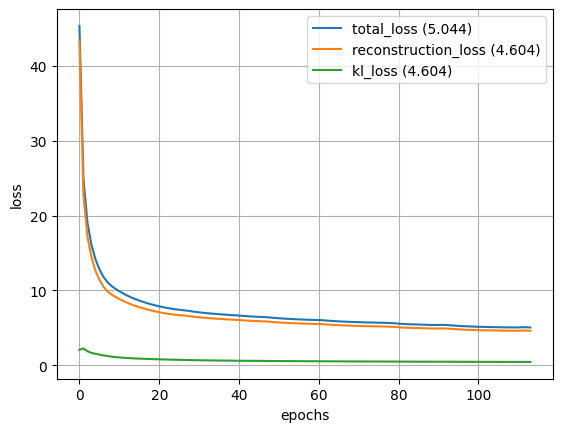

In [ ]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

import project.loader.load as load
from project.models_definitions import encoder
from project.models_definitions import decoder
from project.models_definitions.cvae import CVAE 

import matplotlib.pyplot as plt

import tensorflow as tf
from keras.callbacks import EarlyStopping

## parametros
dataset="mnist"
data = load.data(dataset=dataset)
x_train = data["x_train"]
x_val = data["x_val"]
y_train = data["y_train"]
y_val = data["y_val"]

original_dim = 28*28
beta = 1.0

train_dataset = tf.data.Dataset.from_tensor_slices(((x_train, y_train), x_train))
train_dataset = train_dataset.batch(128)

val_dataset = tf.data.Dataset.from_tensor_slices(((x_val, y_val), x_val))
val_dataset = val_dataset.batch(128)

lat = 128
latent_dim =        [lat,lat,lat,lat,lat,lat,lat,lat,lat]
intermediate_dim =  [130,150,170,190,210,230,250,260,270]


for i in range(len(intermediate_dim)):


    en = encoder.build_enconder(
        intermediate_dim=intermediate_dim[i],
        latent_dim=latent_dim[i],
    )
    de = decoder.build_decoder(
        intermediate_dim=intermediate_dim[i],
        latent_dim=latent_dim[i],
    )
    cvae_model = CVAE(
        encoder=en,
        decoder=de,
        original_dim=original_dim,
        beta=beta,
        name=f"cvae_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}"
    )


    optimizer = tf.keras.optimizers.Adam()
    cvae_model.compile(optimizer=optimizer)


    cvae_model.total_loss_tracker.reset_state()
    cvae_model.reconstruction_loss_tracker.reset_state()
    cvae_model.kl_loss_tracker.reset_state()

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = cvae_model.fit(
        train_dataset,
        epochs=1000,
        batch_size=128,
        validation_data=val_dataset,
        callbacks=[early_stopping],
        verbose=1
    )

    en.save(f"en_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}.keras")
    de.save(f"de_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}.keras")

    
    plt.plot(history.history["loss"], label=f"total_loss ({round(history.history["loss"][-1],3)})")
    plt.plot(history.history["reconstruction_loss"], label=f"reconstruction_loss ({round(history.history["reconstruction_loss"][-1],3)})")
    plt.plot(history.history["kl_loss"], label=f"kl_loss ({round(history.history["kl_loss"][-1],3)})")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.grid()
    plt.legend()
    plt.savefig(f"loss_vs_epochs_model_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}")
    plt.show()

    del cvae_model, en, de, history
    tf.keras.backend.clear_session()


## Test de modelo entrenado. 

In [4]:
import numpy as np
dataset="fashion"
data = load.data(dataset=dataset)
x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]

y_train = data["y_train"]
y_val = data["y_val"]
y_test =data["x_test"]



x_test = data["x_test"]
y_test = data["y_test"]


x = x_test[1 :  2]  # (1, 28, 28)
y = y_test[1 :  2]  # (1, 10)

# Codificar
z_mean, _, z = cvae_model.encoder.predict([x, y], verbose=0)

# Decodificar
x_recon = cvae_model.decoder.predict([z, y], verbose=0)



x_pic = tf.reshape(x, (28, 28))
x_recon = tf.reshape(x_recon, (28, 28))
ax = plt.subplot(1,2)
plt.title(f"Imganes{cvae_model.name}")
plt.xlabel("Modelo")
ax[0,0]=plt.imshow(x_pic, cmap="gray")
# Usar nombres como ticks
plt.tight_layout()
plt.show()


plt.xlabel("Modelo")
ax[0,1]=plt.imshow(x_recon, cmap="gray")
# Usar nombres como ticks
plt.tight_layout()
plt.show()


Usando fashion como dataset


TypeError: subplot() takes 1 or 3 positional arguments but 2 were given

<Figure size 640x480 with 0 Axes>